In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned.csv')
print(f"✅ Loaded! {df.shape[0]} rows × {df.shape[1]} columns")

✅ Loaded! 19548 rows × 28 columns


In [12]:
# This is the core innovation of our project
# log() is used because Streams and Views differ by millions
# Without log, the gap would be unfairly dominated by huge numbers

df['log_streams'] = np.log1p(df['Stream'])  # log of spotify streams
df['log_views']   = np.log1p(df['Views'])   # log of youtube views

# Gap Score = positive means Spotify dominant
#             negative means YouTube dominant
#             near zero means Cross-platform hit
df['gap_score'] = df['log_streams'] - df['log_views']

print("✅ Gap Score created!")
print(df['gap_score'].describe())

✅ Gap Score created!
count    19548.000000
mean         1.570714
std          2.223686
min         -9.511224
25%          0.127419
50%          1.151285
75%          2.573558
max         17.431995
Name: gap_score, dtype: float64


In [13]:
# We use percentiles to define the 3 classes
# Top 33% gap score  → Spotify-native
# Bottom 33%         → YouTube-native
# Middle 33%         → Cross-platform hit

low  = df['gap_score'].quantile(0.33)
high = df['gap_score'].quantile(0.66)

def classify_platform(score):
    if score >= high:
        return 'Spotify-native'
    elif score <= low:
        return 'YouTube-native'
    else:
        return 'Cross-platform'

df['platform_class'] = df['gap_score'].apply(classify_platform)

print("✅ Platform classes created!")
print(df['platform_class'].value_counts())

✅ Platform classes created!
platform_class
Spotify-native    6646
YouTube-native    6451
Cross-platform    6451
Name: count, dtype: int64


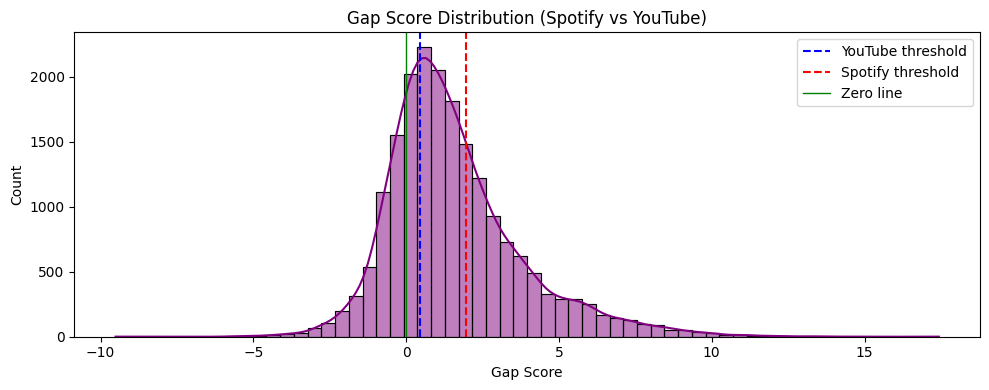

✅ Saved!


In [14]:
plt.figure(figsize=(10, 4))
sns.histplot(df['gap_score'], bins=60, color='purple', kde=True)
plt.axvline(low,  color='blue', linestyle='--', label='YouTube threshold')
plt.axvline(high, color='red',  linestyle='--', label='Spotify threshold')
plt.axvline(0,    color='green',linestyle='-',  label='Zero line', linewidth=1)
plt.title('Gap Score Distribution (Spotify vs YouTube)')
plt.xlabel('Gap Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/gap_score_distribution.png')
plt.show()
print("✅ Saved!")

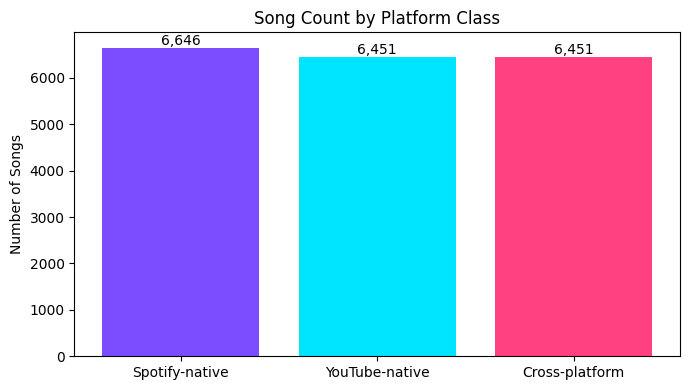

In [15]:
plt.figure(figsize=(7, 4))
counts = df['platform_class'].value_counts()
colors = ['#7c4dff', '#00e5ff', '#ff4081']
plt.bar(counts.index, counts.values, color=colors, edgecolor='none')
plt.title('Song Count by Platform Class')
plt.ylabel('Number of Songs')
for i, (idx, val) in enumerate(counts.items()):
    plt.text(i, val + 50, f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/platform_class_breakdown.png')
plt.show()

In [16]:
# This is the storytelling section
# What audio features define each platform group?

audio_cols = ['Danceability','Energy','Loudness','Speechiness',
              'Acousticness','Instrumentalness','Liveness','Valence','Tempo']

# Average audio features per platform class
audio_dna = df.groupby('platform_class')[audio_cols].mean()
print("✅ Audio DNA per Platform Group:")
print(audio_dna.round(3))

✅ Audio DNA per Platform Group:
                Danceability  Energy  Loudness  Speechiness  Acousticness  \
platform_class                                                              
Cross-platform         0.627   0.660    -7.029        0.098         0.240   
Spotify-native         0.590   0.581    -9.224        0.091         0.348   
YouTube-native         0.647   0.665    -6.596        0.097         0.277   

                Instrumentalness  Liveness  Valence    Tempo  
platform_class                                                
Cross-platform             0.038     0.184    0.528  121.765  
Spotify-native             0.106     0.188    0.495  118.629  
YouTube-native             0.020     0.201    0.563  121.440  


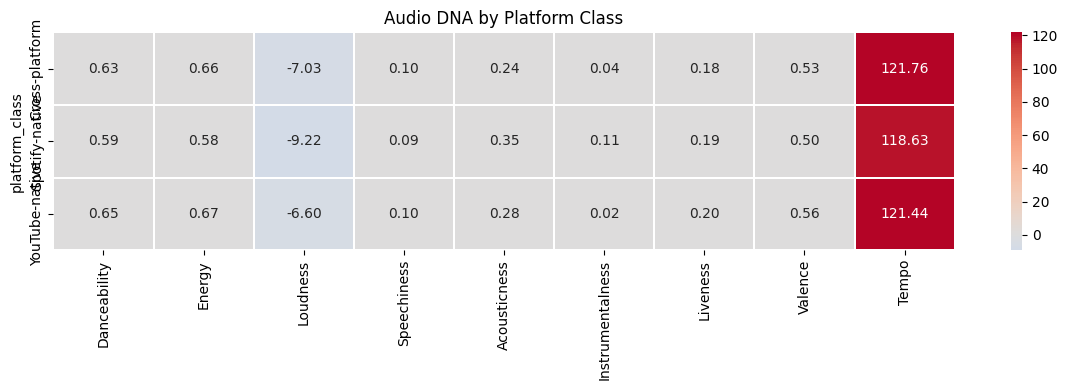

✅ Saved!


In [17]:
plt.figure(figsize=(12, 4))
sns.heatmap(audio_dna, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.3)
plt.title('Audio DNA by Platform Class')
plt.tight_layout()
plt.savefig('../reports/figures/audio_dna_heatmap.png')
plt.show()
print("✅ Saved!")

In [18]:
# Save to data/outputs so Phase 5 ML can use it
df.to_csv('../data/outputs/gap_scores.csv', index=False)
print(f"✅ Gap scores saved to data/outputs/gap_scores.csv")
print(f"Columns added: gap_score, log_streams, log_views, platform_class")

✅ Gap scores saved to data/outputs/gap_scores.csv
Columns added: gap_score, log_streams, log_views, platform_class
